# Interactive low-rank RL experiment runner

This notebook is an interactive version of `experiments/run.py`. It trains an agent from scratch (or from a YAML config) and then runs the full low-rank analysis suite, rendering every plot inline.

Sections:

1. **Setup** — imports and matplotlib inline config.
2. **Config** — either load an existing YAML from `experiments/configs/` or override parameters directly in the notebook.
3. **Environment + agent** — build via the standard factories.
4. **Training loop** — tqdm progress bar + a live reward-vs-episode plot; returns `durations`, `rewards`, `rank_history`.
5. **Training plots** — episode durations, episode rewards, rank vs episode.
6. **Q-matrix rank** — singular-value spectrum.
7. **Value tensor / HOSVD** — per-mode singular-value spectra.
8. **Hankel analysis** — value and Q-taken trajectory Hankel spectra.
9. **Successor measure shift** — vanilla vs shifted.
10. **Value heatmap** — 2-D slice of $V(s)$.
11. **(Optional) save agent**.

See `experiments/README.md` for the config schema and `low_rank_rl/analysis/README.md` for the maths behind each metric.

## 1. Setup

In [5]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pathlib
import sys

# Make the package importable when running the notebook from anywhere in the repo.
REPO_ROOT = pathlib.Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "low_rank_rl").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import yaml

from IPython.display import display, clear_output

from low_rank_rl.envs import make_env
from low_rank_rl.agents import (
    DQNAgent, QLearningAgent, SarsaAgent, MonteCarloAgent, PPOAgent,
)
from low_rank_rl.training import train
from low_rank_rl.analysis.rank import compute_rank_metrics, sample_states, canonical_subsample
from low_rank_rl.analysis.tensor import build_value_tensor, hosvd_spectra
from low_rank_rl.analysis.hankel import hankel_rank_metrics
from low_rank_rl.analysis.successor import compare_shift_rank
from low_rank_rl.visualization.training import (
    plot_episode_durations,
    plot_episode_rewards,
)
from low_rank_rl.visualization.rank_analysis import (
    plot_singular_value_spectrum,
    plot_hosvd_spectra,
    plot_rank_vs_episode,
    plot_hankel_spectrum,
    plot_shift_comparison,
)
from low_rank_rl.visualization.value_fn import plot_value_heatmap

print(f"Repo root: {REPO_ROOT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo root: /Users/souparna/Low-Rank-RL-TL


## 2. Config

Two ways to configure an experiment:

- **(A) Load a YAML** from `experiments/configs/` — same file that `run.py` consumes.
- **(B) Override** any field on the loaded config directly in Python.

You can skip (A) entirely and build the `cfg` dict from scratch.

In [6]:
CONFIG_PATH = REPO_ROOT / "experiments" / "configs" / "mountaincar_dqn.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# Optional: shrink for a quick interactive run.
# cfg["training"]["n_episodes"] = 50
# cfg["training"]["rank_checkpoint_every"] = 10
# cfg["training"]["n_rank_samples"] = 256

cfg

{'env_id': 'MountainCarContinuous-v0',
 'agent': 'dqn',
 'training': {'n_episodes': 1000,
  'rank_checkpoint_every': 100,
  'n_rank_samples': 1024},
 'agent_kwargs': {'hidden': 128,
  'batch_size': 128,
  'gamma': 0.99,
  'lr': 0.0001,
  'tau': 0.005,
  'eps_start': 0.9,
  'eps_end': 0.01,
  'eps_decay': 40000,
  'buffer_capacity': 50000},
 'env_kwargs': {'n_discrete_actions': 21, 'normalize_obs': True},
 'analysis': {'hankel_steps': 300,
  'hankel_n_rows': None,
  'value_tensor_bins': 30,
  'value_tensor_dims': [0, 1]},
 'output': {'save_dir': 'outputs/mountaincar_dqn', 'save_agent': True}}

## 3. Environment and agent

In [7]:
def build_agent(agent_name, env, kwargs):
    obs_space = env.observation_space
    n_obs     = obs_space.shape[0]
    n_actions = env.action_space.n
    if agent_name == "dqn":
        return DQNAgent(n_obs=n_obs, n_actions=n_actions, **kwargs)
    if agent_name in ("qlearning", "q_learning"):
        return QLearningAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "sarsa":
        return SarsaAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "monte_carlo":
        return MonteCarloAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "ppo":
        return PPOAgent(n_obs=n_obs, n_actions=n_actions, **kwargs)
    raise ValueError(f"Unknown agent: {agent_name!r}")


env   = make_env(cfg["env_id"], **cfg.get("env_kwargs", {}))
agent = build_agent(cfg["agent"], env, cfg.get("agent_kwargs", {}))
print(f"Env    : {cfg['env_id']}")
print(f"Agent  : {agent}")
print(f"Episodes: {cfg['training']['n_episodes']}")

Env    : MountainCarContinuous-v0
Agent  : DQNAgent(n_obs=2, n_actions=21, device=mps, eps=0.900)
Episodes: 1000


## 4. Training

`low_rank_rl.training.train(agent, env, cfg, on_episode=...)` auto-selects the
correct loop for the agent (step-based for DQN/Q-learning/SARSA, episode-based
for Monte Carlo, PPO with bootstrapped `last_value` on truncation).

The cell below shows:

- a **tqdm progress bar** with rolling-mean reward in the postfix;
- a **live reward-vs-episode plot** that refreshes every `REFRESH_EVERY`
  episodes via an `on_episode` callback.

The DQN loop is from  [PyTorch RL tutorial](https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html);
the PPO loop is from [OpenAI Spinning Up's PPO](https://spinningup.openai.com/en/latest/algorithms/ppo.html).

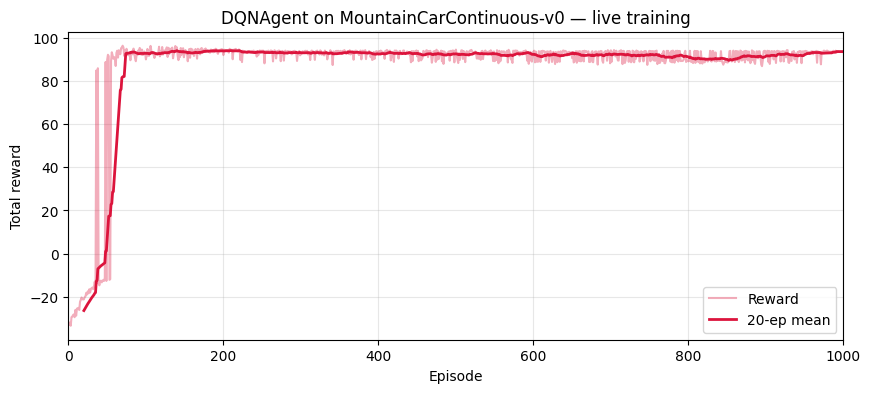

DQNAgent train:   0%|          | 0/1000 [00:00<?, ?it/s]

  ep  100/1000  dur= 299  R=+89.9  Q-matrix 1024x21  |  numerical rank = 21/21 (100.00%)  |  stable rank = 1.00  |  effective rank = 1.01  |  spectral gap = 350.9883
  ep  200/1000  dur= 144  R=+91.9  Q-matrix 1024x21  |  numerical rank = 21/21 (100.00%)  |  stable rank = 1.00  |  effective rank = 1.00  |  spectral gap = 2048.7708
  ep  300/1000  dur= 102  R=+92.4  Q-matrix 1024x21  |  numerical rank = 21/21 (100.00%)  |  stable rank = 1.00  |  effective rank = 1.00  |  spectral gap = 2577.4169
  ep  400/1000  dur=  99  R=+92.3  Q-matrix 1024x21  |  numerical rank = 20/21 (95.24%)  |  stable rank = 1.00  |  effective rank = 1.00  |  spectral gap = 7601.4312
  ep  500/1000  dur=  71  R=+94.4  Q-matrix 1024x21  |  numerical rank = 20/21 (95.24%)  |  stable rank = 1.00  |  effective rank = 1.00  |  spectral gap = 13596.9587
  ep  600/1000  dur=  70  R=+93.2  Q-matrix 1024x21  |  numerical rank = 19/21 (90.48%)  |  stable rank = 1.00  |  effective rank = 1.00  |  spectral gap = 26408.5017


In [8]:
REFRESH_EVERY = 5  # redraw the live plot every N episodes

n_ep = cfg["training"]["n_episodes"]

fig_live, ax_live  = plt.subplots(figsize=(10, 4))
line_raw,          = ax_live.plot([], [], alpha=0.35, color="crimson", label="Reward")
line_avg,          = ax_live.plot([], [], color="crimson", linewidth=2, label="20-ep mean")
ax_live.set_xlim(0, n_ep)
ax_live.set_xlabel("Episode")
ax_live.set_ylabel("Total reward")
ax_live.set_title(f"{type(agent).__name__} on {cfg['env_id']} — live training")
ax_live.grid(True, alpha=0.3)
ax_live.legend(loc="lower right")
live_handle = display(fig_live, display_id="live_reward_plot")
plt.close(fig_live)

_reward_buffer = []

def _on_episode(ep: int, duration: int, reward: float) -> None:
    _reward_buffer.append(reward)
    if ep % REFRESH_EVERY != 0 and ep != n_ep:
        return
    xs = np.arange(1, len(_reward_buffer) + 1)
    ys = np.asarray(_reward_buffer, dtype=float)
    line_raw.set_data(xs, ys)
    w = min(20, len(ys))
    if w > 1:
        avg = np.convolve(ys, np.ones(w) / w, mode="valid")
        line_avg.set_data(np.arange(w, len(ys) + 1), avg)
    ax_live.relim(); ax_live.autoscale_view(scalex=False, scaley=True)
    live_handle.update(fig_live)

log = train(agent, env, cfg, on_episode=_on_episode, progress=True)
durations, rewards, rank_history = log.durations, log.rewards, log.rank_history

print(f"\nTrained {len(durations)} episodes — last reward = {rewards[-1]:+.1f}, "
      f"best = {max(rewards):+.1f}, mean(last 20) = {np.mean(rewards[-20:]):+.1f}")

## 5. Training plots

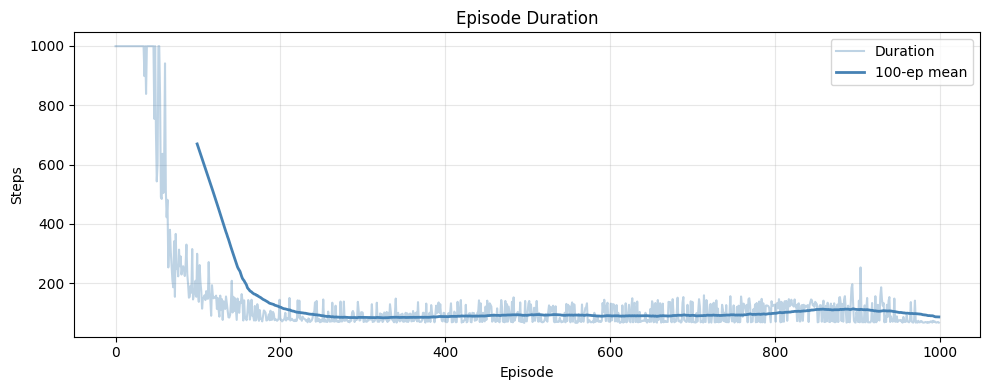

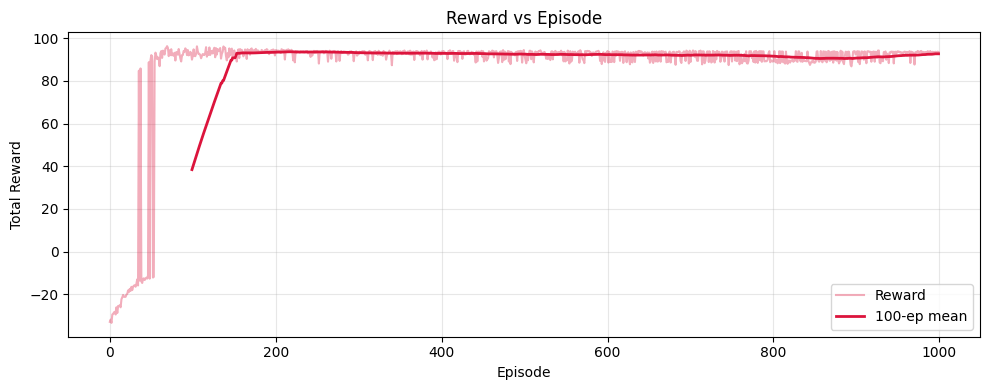

In [9]:
plot_episode_durations(durations, window=max(5, len(durations) // 10))
plt.show()

plot_episode_rewards(rewards, window=max(5, len(rewards) // 10))
plt.show()

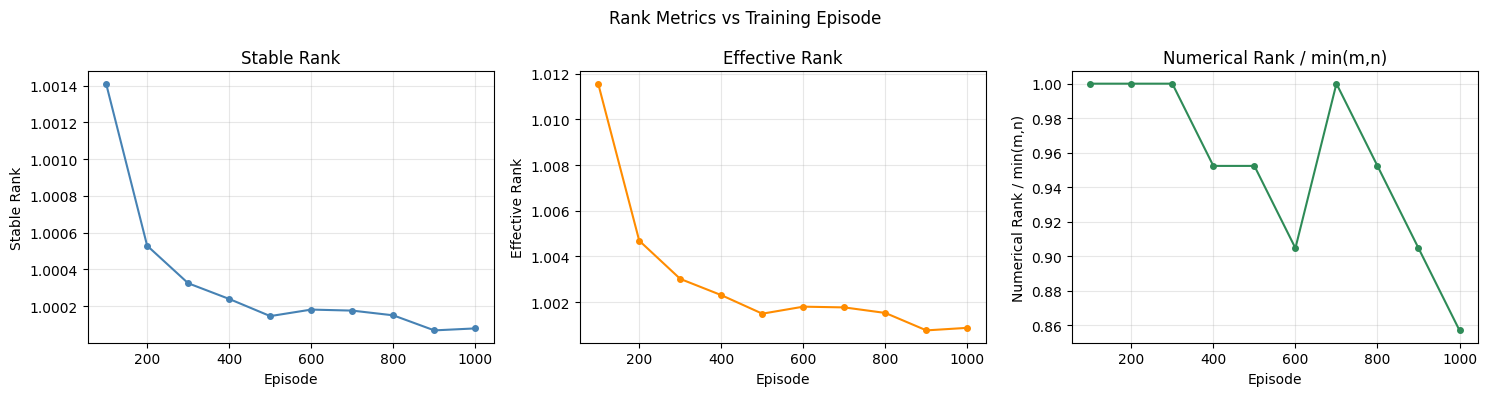

In [10]:
if rank_history:
    plot_rank_vs_episode(rank_history)
    plt.show()
else:
    print("No rank checkpoints were recorded — increase n_episodes or lower rank_checkpoint_every.")

## 6. Q-matrix rank analysis

$Q \in \mathbb{R}^{N \times |\mathcal A|}$. When the env is discretised, `sample_states` returns the **full canonical grid** (one row per bin centre), so this is the exact tabular rank. Otherwise $N$ states are drawn under a uniform random policy.

See `low_rank_rl/analysis/README.md` for the numerical / stable / effective rank definitions.

Q-matrix 1024x21  |  numerical rank = 16/21 (76.19%)  |  stable rank = 1.00  |  effective rank = 1.00  |  spectral gap = 93190.8383


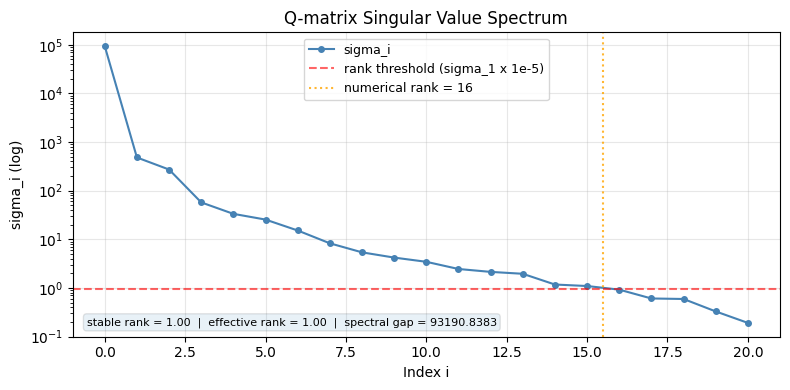

In [11]:
probe_states = sample_states(env, cfg["training"]["n_rank_samples"])
print(f"Probe states: {probe_states.shape[0]}")
metrics = compute_rank_metrics(agent, probe_states)
print(metrics.summary())
plot_singular_value_spectrum(metrics)
plt.show()

## 7. Value tensor (HOSVD)

Builds $\mathcal V_{i_1 \dots i_k} \approx \mathrm{mean}\{V(s) : s \in \text{bin}(i_1, \dots, i_k)\}$ and plots the singular values of each mode-$n$ unfolding.

Value tensor shape: (30, 30)


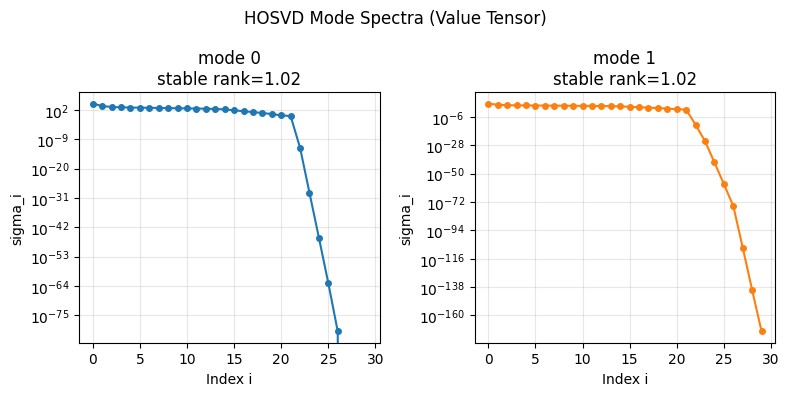

In [12]:
analysis_cfg = cfg.get("analysis", {})
V_tensor = build_value_tensor(
    agent, env,
    dims=analysis_cfg.get("value_tensor_dims"),
    n_bins=analysis_cfg.get("value_tensor_bins"),  # None -> use canonical wrapper grid when available
    n_samples=min(20_000, cfg["training"]["n_rank_samples"] * 50),
)
print(f"Value tensor shape: {V_tensor.shape}")

spectra = hosvd_spectra(V_tensor)
plot_hosvd_spectra(spectra)
plt.show()

## 8. Hankel analysis

Rolls out a greedy trajectory, builds the Hankel matrix $H_{ij} = f_{i+j}$ for $f_t \in \{V(s_t), \, Q(s_t, a_t)\}$, and inspects its spectrum. Low rank $\leftrightarrow$ approximate finite-dimensional (Koopman-like) linear dynamics.

Hankel(value) 35x36  |  seq_len=70  |  num_rank=35  |  stable_rank=1.00  |  eff_rank=1.01


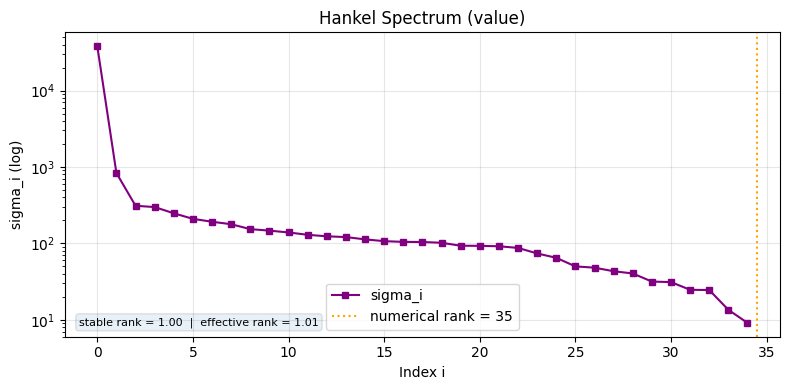

Hankel(q_taken) 34x35  |  seq_len=68  |  num_rank=34  |  stable_rank=1.00  |  eff_rank=1.01


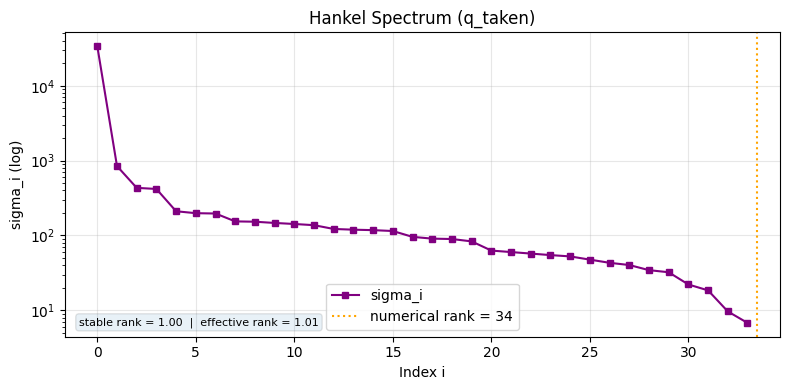

In [13]:
for seq_type in ("value", "q_taken"):
    hm = hankel_rank_metrics(
        agent, env,
        sequence_type=seq_type,
        n_steps=analysis_cfg.get("hankel_steps", 500),
        n_rows=analysis_cfg.get("hankel_n_rows", None),
    )
    print(hm.summary())
    plot_hankel_spectrum(hm)
    plt.show()

## 9. Successor measure shift

Builds $\hat M^\pi$ empirically and compares it to the shifted version $\tilde M^\pi = \hat M^\pi - \mathbf 1 \hat\mu^\top$.

**Runtime**: $O(N^2 \cdot T)$, so we cap $N \le 64$. `canonical_subsample` takes a random subset of the canonical grid when discretised, or MC-samples states otherwise.

Successor matrix comparison
  Vanilla  -> Q-matrix 64x64  |  numerical rank = 7/64 (10.94%)  |  stable rank = 1.05  |  effective rank = 1.28  |  spectral gap = 171.2033
  Shifted  -> Q-matrix 64x64  |  numerical rank = 7/64 (10.94%)  |  stable rank = 1.51  |  effective rank = 2.70  |  spectral gap = 17.5038


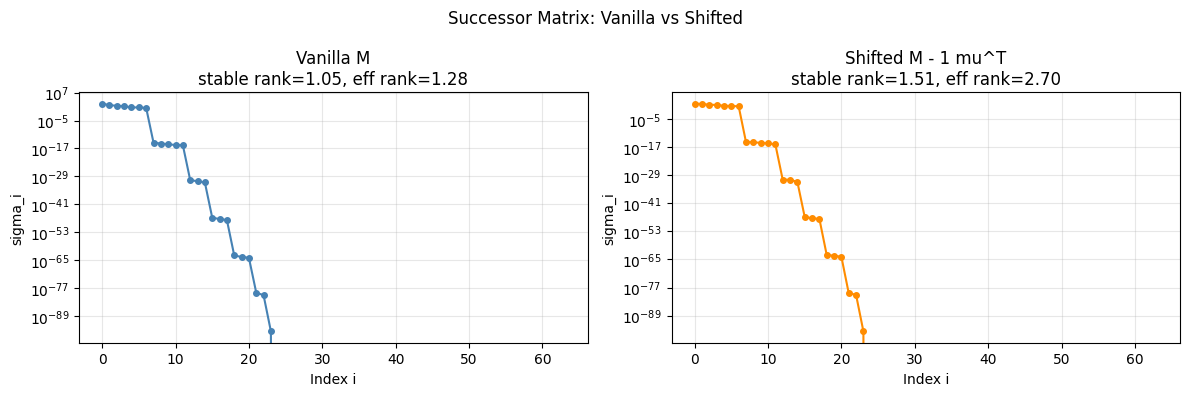

In [14]:
N_probe = min(64, cfg["training"]["n_rank_samples"])
probe_states_small = canonical_subsample(env, N_probe)
comparison = compare_shift_rank(agent, env, probe_states_small, gamma=0.99, n_rollout_steps=200)
print(comparison.summary())
plot_shift_comparison(comparison)
plt.show()

## 10. Value heatmap

2-D slice of $V(s) = \max_a Q(s, a)$. For >2-D observations, all dimensions except the two on the axes are pinned at their mid-range. Tweak `dims` / `fixed_values` to explore other slices.

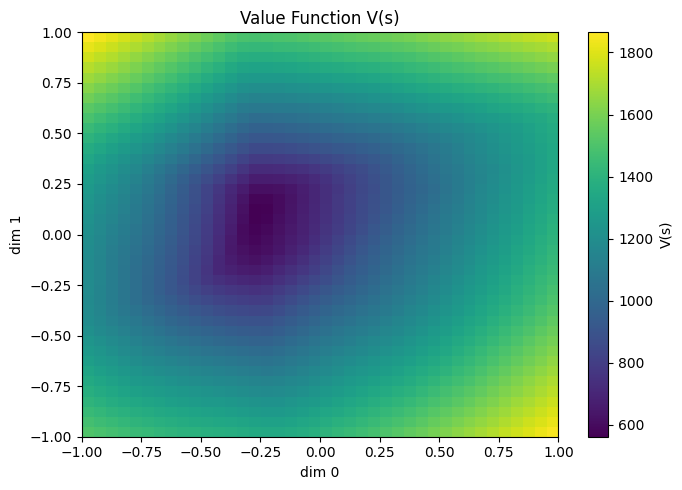

In [15]:
plot_value_heatmap(agent, env, dims=(0, 1), n_bins=40)
plt.show()

## 11. (Optional) save agent and close env

In [16]:
SAVE = False  # flip to True to persist
if SAVE:
    out_dir = REPO_ROOT / cfg["output"]["save_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    agent.save(out_dir / "agent.pt")
    print(f"Saved to {out_dir}/agent.pt")

env.close()